## NX-414: Brain-like computation and intelligence
Notebook prepared by Alessandro Marin Vargas

# Week 6 - Mini project (Predicting neural activity)

The objectives of the mini project are:
- Learn how to predict neural activity using linear regression from images and from neural network layers.
- Quantify the goodness of the model
- Compare the results across the network layers and between trained/random neural network
- Predict the neural activity using a neural network in a data-driven approach

Specifically, here you will use the data from the following [paper](https://www.jneurosci.org/content/jneuro/35/39/13402.full.pdf). The behavioral experiment consisted in showing to non-human primates some images while recording the neural activity with multielectrode arrays from the inferior temporal (IT) cortex. In the data we provided you, the neural activity and the images are already pre-processed and you will have available the images and the corresponding average firing rate (between 70 and 170 ms) per each neuron.

### Deadline for Mini-Project Submission: May 7, 2025

You are required to submit your mini-projects by midnight on 07/05/25. Please upload a .zip file to Moodle containing your code, along with the following specific components:

- One-Page Report (Report.pdf): This should detail your investigative process and include:
    - A comparison table of models. This should cover linear regression from stimuli, both trained and random task-driven models, data-driven models, and your best-performing model.
    - A figure illustrating the variation in neural prediction across different layers of a task-driven model.
    - Your exploration to develop the most effective model at predicting IT neural activity
- Example Script/Notebook: Please provide a script (test.py) or a notebook (test.ipynb) demonstrating how your best model performs on the validation set. This should serve as an example of the model's usage.

In [1]:
import sys
!{sys.executable} -m pip install gdown h5py

In [2]:
%cd NX-414-Project
from utils import load_it_data, visualize_img
import matplotlib.pyplot as plt
import numpy as np
import gdown
from tqdm import tqdm
import os
url = "https://drive.google.com/file/d/1s6caFNRpyR9m7ZM6XEv_e8mcXT3_PnHS/view?usp=share_link"
output = "IT_data.h5"
if not os.path.exists(output):
    gdown.download(url, output, quiet=False, fuzzy=True)


/home/dbach/NX-414-Project


### Load the data

In [3]:
path_to_data = '' ## Insert the folder where the data is, if you download in the same folder as this notebook then leave it blank

stimulus_train, stimulus_val, stimulus_test, objects_train, objects_val, objects_test, spikes_train, spikes_val = load_it_data(path_to_data)

In [4]:
n_stimulus, n_channels, img_size, _ = stimulus_train.shape
_, n_neurons = spikes_train.shape
print('The train dataset contains {} stimuli and {} IT neurons'.format(n_stimulus,n_neurons))
print('Each stimulus have {} channgels (RGB)'.format(n_channels))
print('The size of the image is {}x{}'.format(img_size,img_size))

The train dataset contains 2592 stimuli and 168 IT neurons
Each stimulus have 3 channgels (RGB)
The size of the image is 224x224


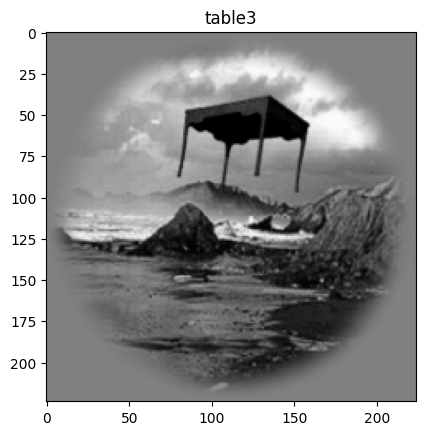

In [5]:
stim_idx = 1

visualize_img(stimulus_train,objects_train,stim_idx)

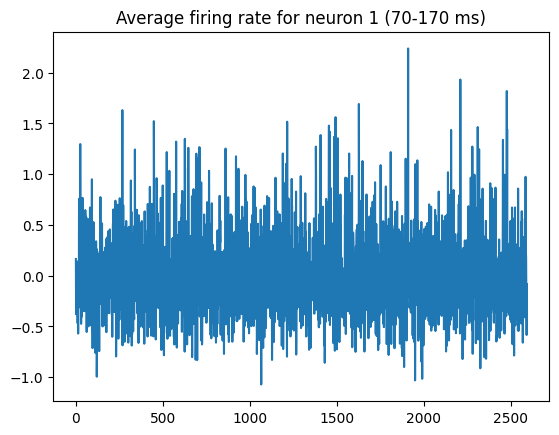

In [6]:
neuron_idx = 1

plt.figure()
plt.title('Average firing rate for neuron {} (70-170 ms)'.format(neuron_idx))
plt.plot(spikes_train[:,neuron_idx])
plt.show()

## Part 1: Predict the neural activity from pixels

##### Develop a linear regression model that predict the neural activity from pixels.
You can try out different types of linear regression (ridge, least-square regression)

In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV
from scipy.stats import pearsonr
from sklearn.metrics import explained_variance_score

import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
import seaborn as sns

##### Evaluate your prediction (Check both the correlation and explained variance for each neuron). Plot the distribution for the explained variance across neurons.

In [47]:
# Reshape the data
X_train = stimulus_train.reshape(stimulus_train.shape[0], -1)
X_val = stimulus_val.reshape(stimulus_val.shape[0], -1)
X_test = stimulus_test.reshape(stimulus_test.shape[0], -1)
y_train = spikes_train.reshape(spikes_train.shape[0], -1)
y_val = spikes_val.reshape(spikes_val.shape[0], -1)

In [48]:
# Standardize the data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [49]:
def evaluate_model(model, X: np.ndarray, y: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """
    Evaluate a model using Pearson correlation and explained variance.

    Parameters:
    - model: Trained model with a `predict` method.
    - X (np.ndarray): Input data of shape (n_samples, n_features).
    - y (np.ndarray): True output data of shape (n_samples, n_targets).

    Returns:
    - tuple[np.ndarray, np.ndarray]: A tuple containing:
        - corr (np.ndarray): Pearson correlation for each output dimension, shape (n_targets,).
        - evar (np.ndarray): Explained variance for each output dimension, shape (n_targets,).
    """

    # Predict the output using the model
    y_pred = model.predict(X)

    # Compute Pearson correlation for all dimensions
    corr = np.array([pearsonr(y[:, i], y_pred[:, i])[0] for i in range(y.shape[1])])

    # Compute explained variance for all dimensions
    evar = explained_variance_score(y, y_pred, multioutput='raw_values')

    return corr, evar


In [50]:
def plot_ev_distributions(ev_list: list[np.ndarray], models: list[str], kde:bool=True) -> None:
    """
    Plot the distribution of explained variance (ev) across neurons for multiple models.

    Parameters:
    - ev_list (list[np.ndarray]): List of arrays of explained variance values for each neuron, one per model.
    - model_names (list[str]): List of model names corresponding to the EV arrays.
    - kde (bool): If True, use Kernel Density Estimation for visualization.
    """
    plt.figure(figsize=(12, 6))
    for ev, model in zip(ev_list, models):
        if kde:
            sns.kdeplot(ev, label=model, fill=True, alpha=0.5)
        else:
            plt.hist(ev, bins=30, alpha=0.7, label=model, edgecolor='black')
    title = "Distribution of explained variance across neurons"
    if len(models) == 1:
        title += f" - {models[0]}"
    plt.title(title)
    plt.xlabel("Explained variance")
    plt.ylabel("Number of neurons")
    plt.legend()
    plt.grid(alpha=0.75)
    plt.show()

##### Linear Regression

In [51]:
# Linear regression
linear = LinearRegression()
linear.fit(X_train, y_train)

LinearRegression()

In [52]:
# Results
corr_linear, ev_linear = evaluate_model(linear, X_val, y_val)
mean_corr_linear, mean_ev_linear = np.mean(corr_linear), np.mean(ev_linear)
model_linear = "Linear Regression"
print(model_linear)
print("Mean pearson correlation: {:.4f}".format(mean_corr_linear))
print("Mean explained variance: {:.4f}".format(mean_ev_linear))

Linear Regression
Mean pearson correlation: 0.2203
Mean explained variance: -0.0374


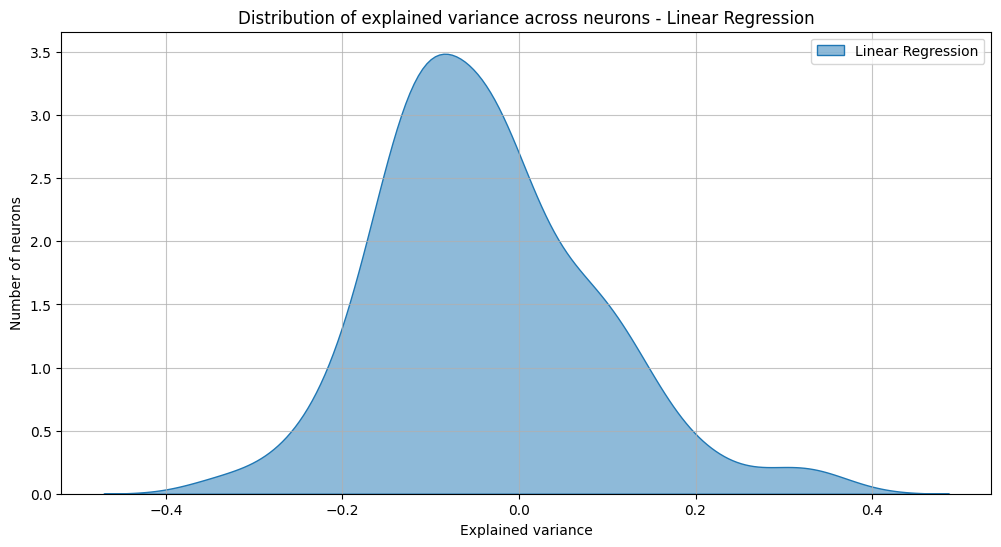

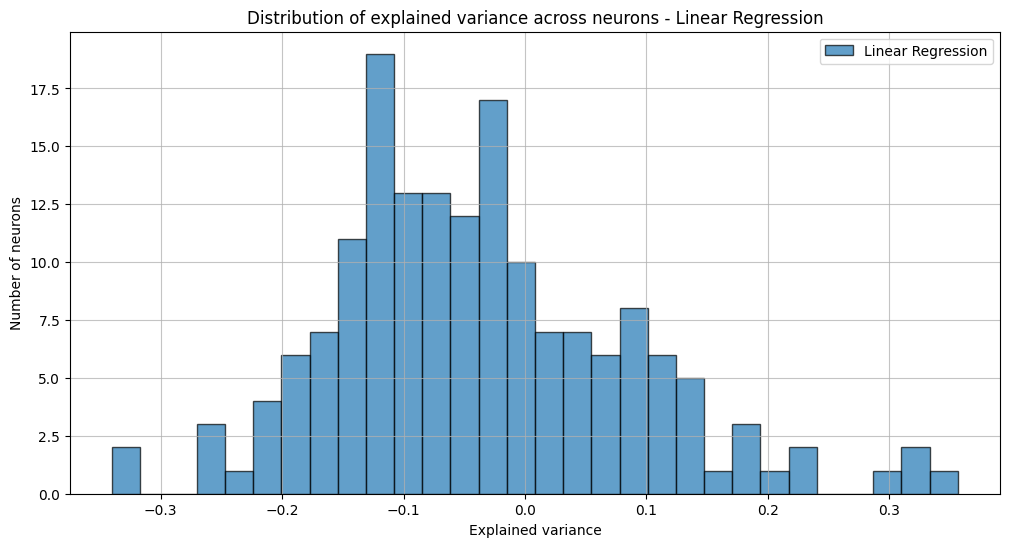

In [53]:
plot_ev_distributions([ev_linear], [model_linear], kde=True)
plot_ev_distributions([ev_linear], [model_linear], kde=False)

##### Ridge regression with $\alpha$=100

In [54]:
# Ridge regression with alpha = 100
ridge = Ridge(alpha=100)
ridge.fit(X_train, y_train)

Ridge(alpha=100)

In [55]:
# Results
corr_ridge, ev_ridge = evaluate_model(ridge, X_val, y_val)
mean_corr_ridge, mean_ev_ridge = np.mean(corr_ridge), np.mean(ev_ridge)
model_ridge = r"Ridge Regression ($\alpha=100$)"
print(model_ridge)
print("Mean pearson correlation: {:.4f}".format(mean_corr_ridge))
print("Mean explained variance: {:.4f}".format(mean_ev_ridge))

Ridge Regression ($\alpha=100$)
Mean pearson correlation: 0.1707
Mean explained variance: -0.7898


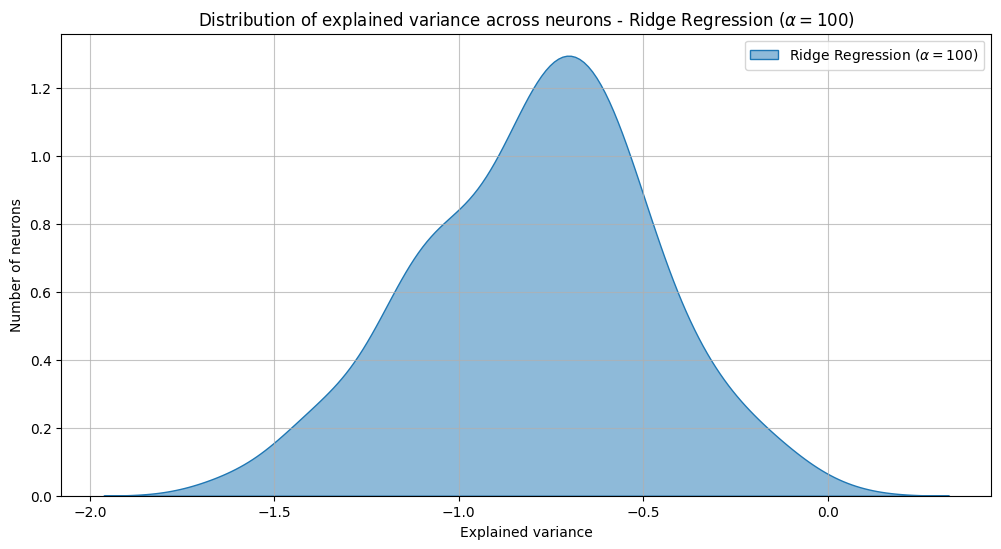

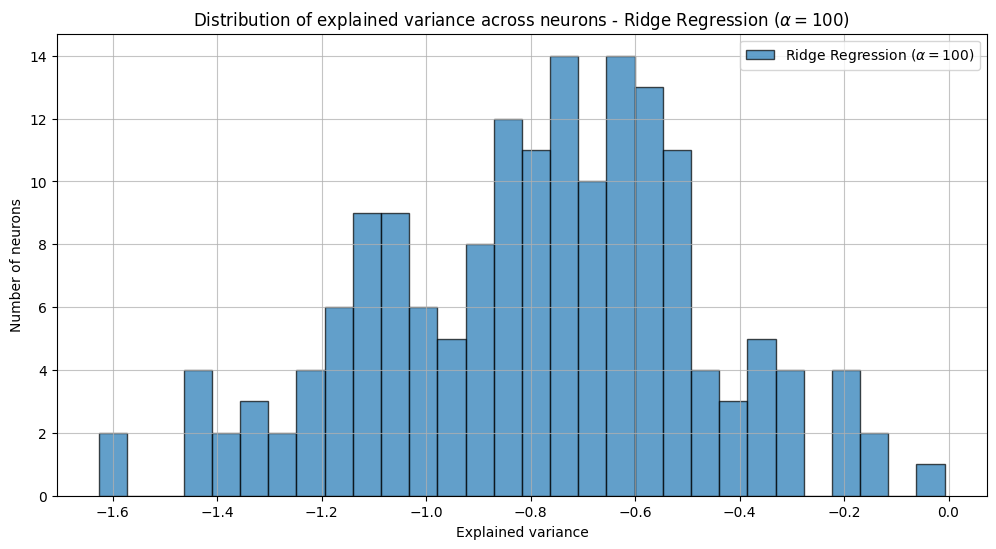

In [56]:
plot_ev_distributions([ev_ridge], [model_ridge], kde=True)
plot_ev_distributions([ev_ridge], [model_ridge], kde=False)

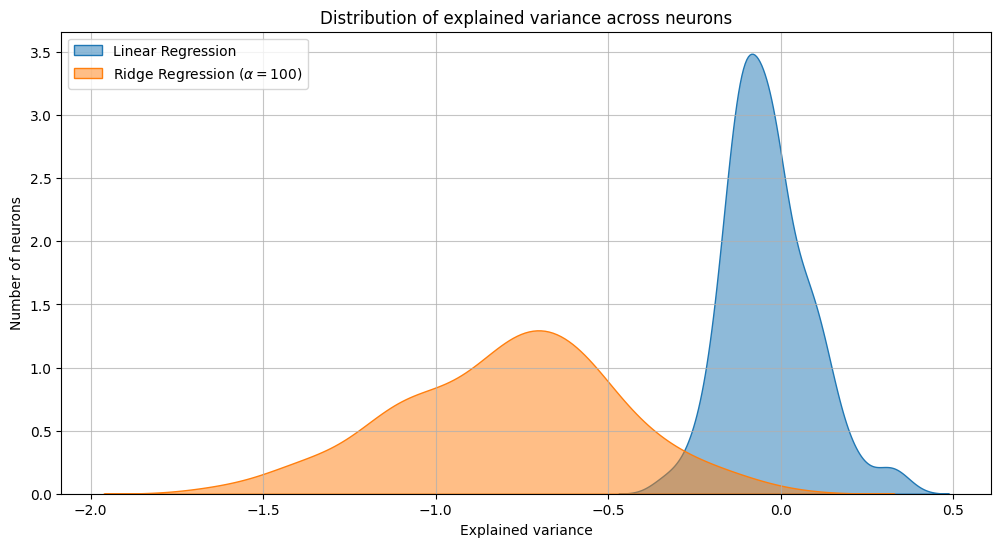

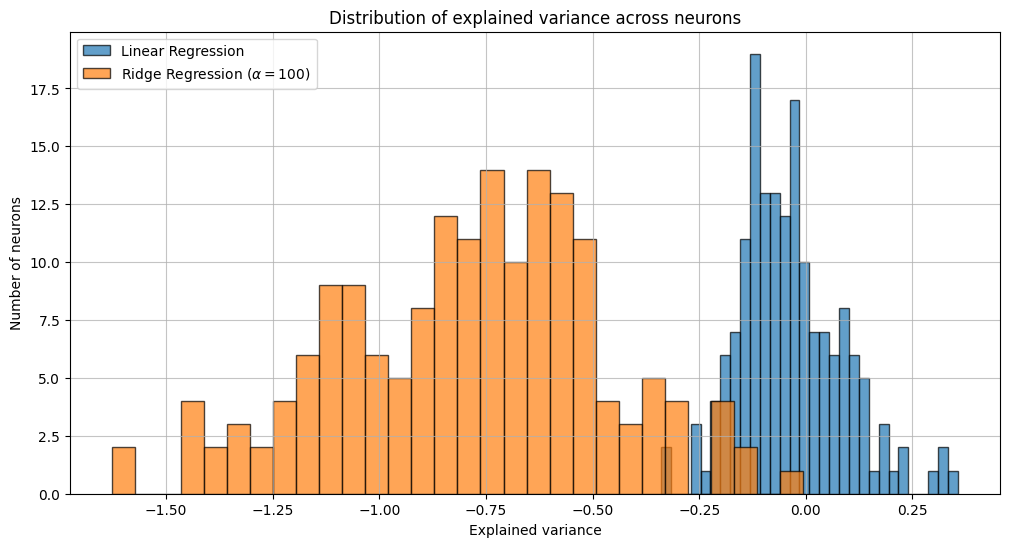

In [57]:
# Visual comprison of the two models
plot_ev_distributions([ev_linear, ev_ridge], [model_linear, model_ridge], kde=True)
plot_ev_distributions([ev_linear, ev_ridge], [model_linear, model_ridge], kde=False)

##### Predicting from pixels is very hard and the model is likely to overfit. An image is very high-dimensional, try to retain the corresponding 1000 PCs and use them to predict the neural activity. 

In [58]:
# PCA
pca = PCA(n_components=1000)
pca.fit(X_train)
X_train_pca = pca.transform(X_train)
X_val_pca = pca.transform(X_val)

##### Linear Regression on PCA

In [59]:
# Linear regression on PCA
linear_pca = LinearRegression()
linear_pca.fit(X_train_pca, y_train)

LinearRegression()

In [60]:
# Results
corr_linear_pca, ev_linear_pca = evaluate_model(linear_pca, X_val_pca, y_val)
mean_corr_linear_pca, mean_ev_linear_pca = np.mean(corr_linear_pca), np.mean(ev_linear_pca)
model_linear_pca = "Linear Regression on PCA"
print(model_linear_pca)
print("Mean pearson correlation: {:.4f}".format(mean_corr_linear_pca))
print("Mean explained variance: {:.4f}".format(mean_ev_linear_pca))

Linear Regression on PCA
Mean pearson correlation: 0.2218
Mean explained variance: -0.0720


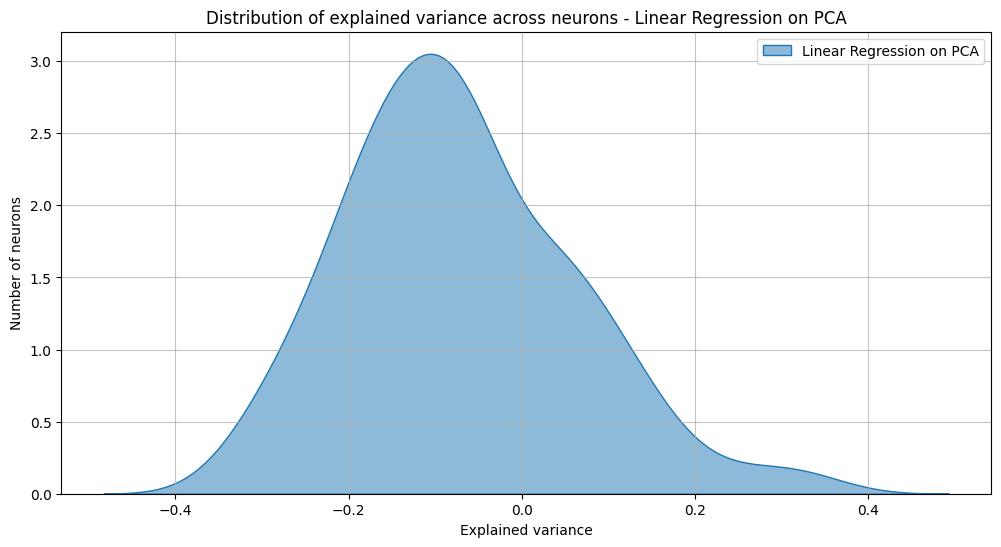

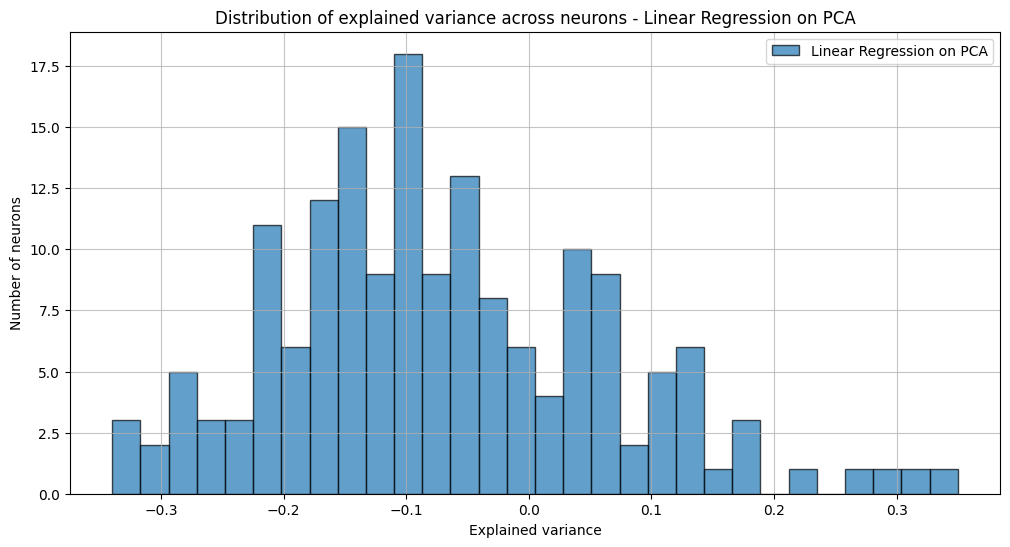

In [61]:
plot_ev_distributions([ev_linear_pca], [model_linear_pca], kde=True)
plot_ev_distributions([ev_linear_pca], [model_linear_pca], kde=False)

##### Ridge regression with $\alpha=100$ on PCA

In [62]:
# Ridge regression on PCA
ridge_pca = Ridge(alpha=100)
ridge_pca.fit(X_train_pca, y_train)

Ridge(alpha=100)

In [63]:
# Results
corr_ridge_pca, ev_ridge_pca = evaluate_model(ridge_pca, X_val_pca, y_val)
mean_corr_ridge_pca, mean_ev_ridge_pca = np.mean(corr_ridge_pca), np.mean(ev_ridge_pca)
model_ridge_pca = r"Ridge Regression on PCA ($\alpha=100$)"
print(model_ridge_pca)
print("Mean pearson correlation: {:.4f}".format(mean_corr_ridge_pca))
print("Mean explained variance: {:.4f}".format(mean_ev_ridge_pca))

Ridge Regression on PCA ($\alpha=100$)
Mean pearson correlation: 0.2220
Mean explained variance: -0.0708


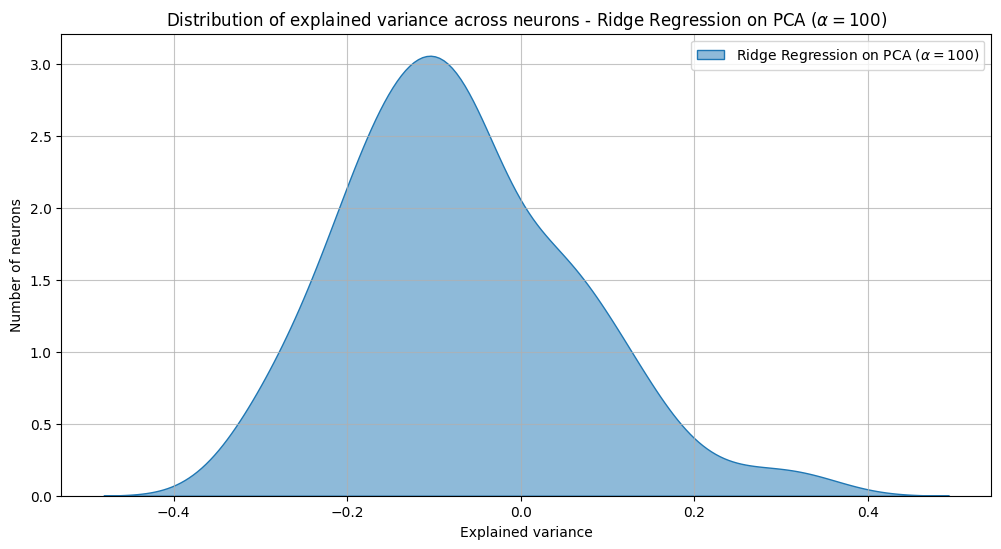

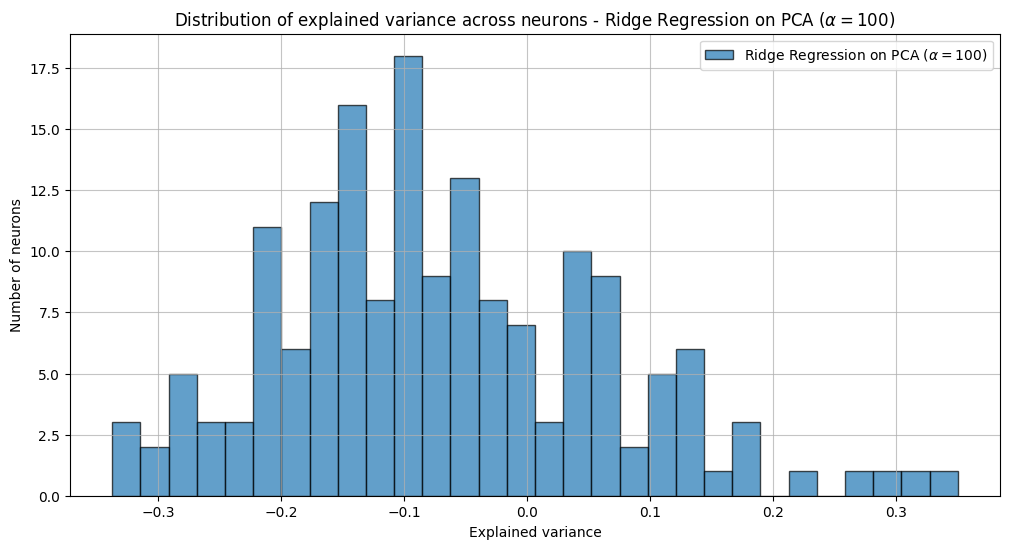

In [64]:
plot_ev_distributions([ev_ridge_pca], [model_ridge_pca], kde=True)
plot_ev_distributions([ev_ridge_pca], [model_ridge_pca], kde=False)

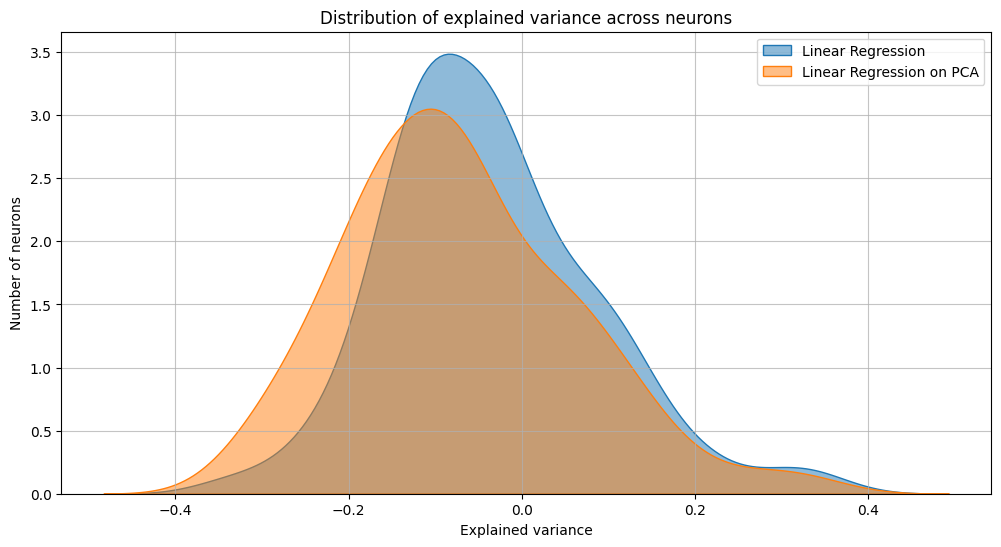

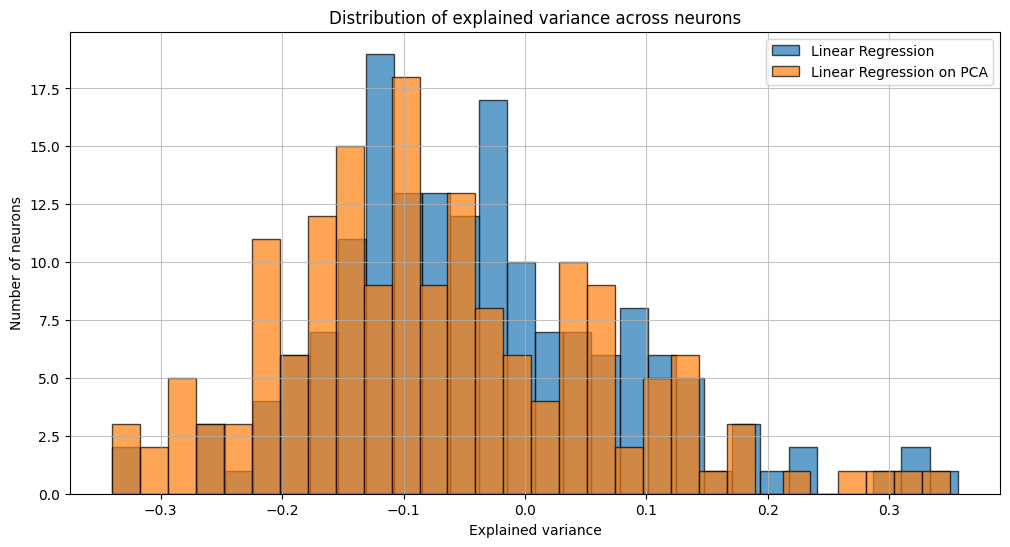

In [65]:
# Comparison linear before and after PCA
plot_ev_distributions([ev_linear, ev_linear_pca], [model_linear, model_linear_pca], kde=True)
plot_ev_distributions([ev_linear, ev_linear_pca], [model_linear, model_linear_pca], kde=False)

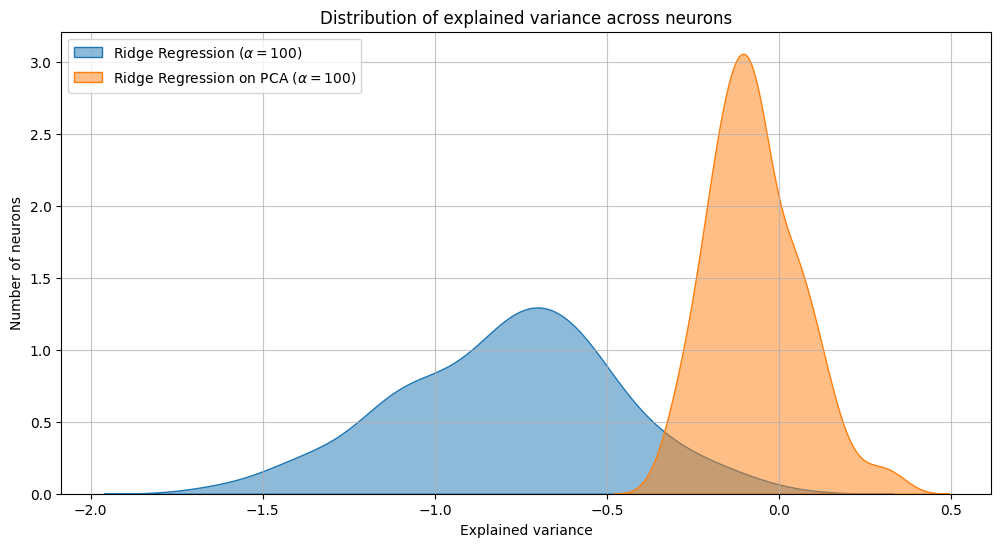

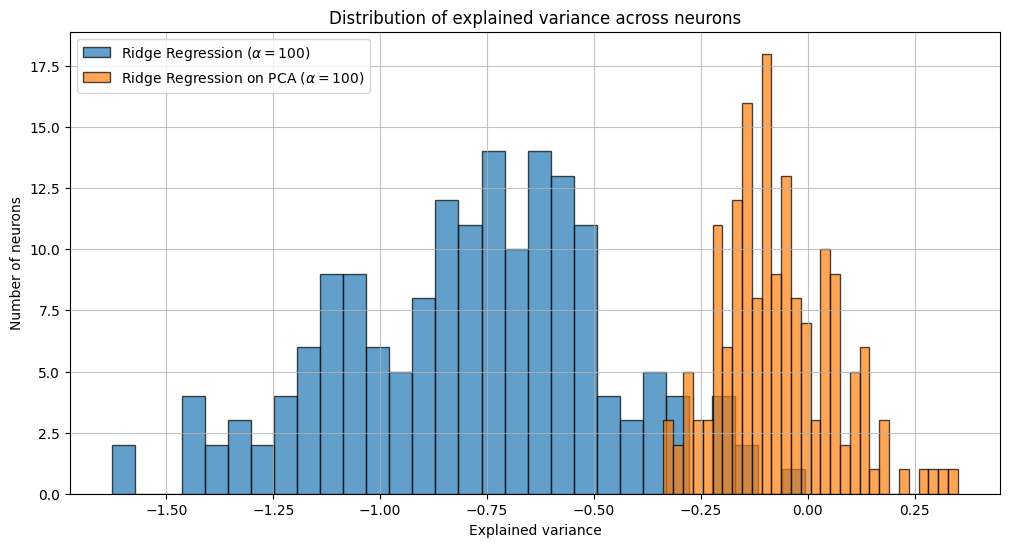

In [66]:
# Comparison of ridge before and after PCA
plot_ev_distributions([ev_ridge, ev_ridge_pca], [model_ridge, model_ridge_pca], kde=True)
plot_ev_distributions([ev_ridge, ev_ridge_pca], [model_ridge, model_ridge_pca], kde=False)

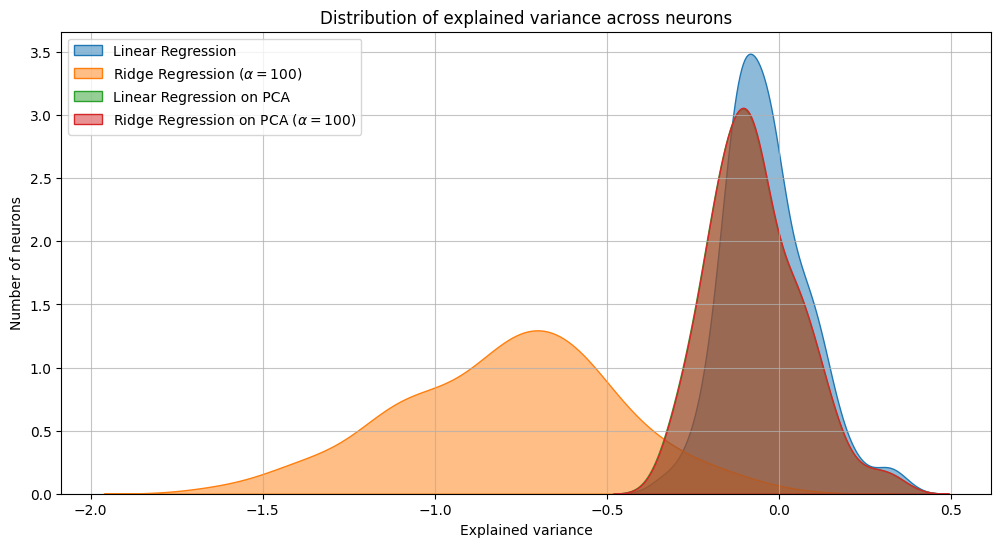

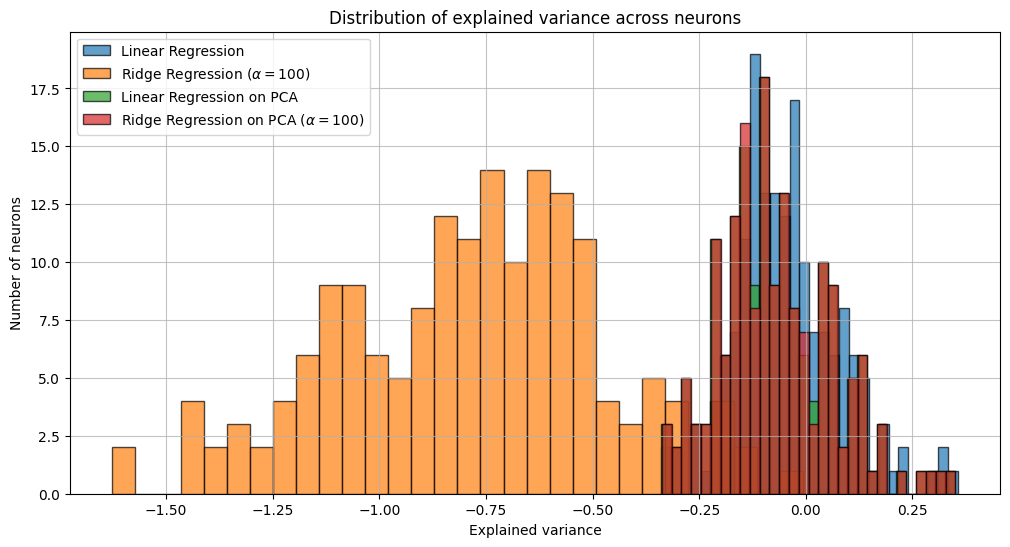

In [67]:
# Compare all models
plot_ev_distributions([ev_linear, ev_ridge, ev_linear_pca, ev_ridge_pca], 
                      [model_linear, model_ridge, model_linear_pca, model_ridge_pca], kde=True)
plot_ev_distributions([ev_linear, ev_ridge, ev_linear_pca, ev_ridge_pca],
                      [model_linear, model_ridge, model_linear_pca, model_ridge_pca], kde=False)

##### Can we improve the prediction? Using the ridge regression, find the best parameter with cross-fold validation (remember to split the data keeping the same distribution of classes between the train and validation set). Does it get better?

##### Tuned ridge regression without pca

In [68]:
# Define the range of alpha values
alphas = np.logspace(0, 8, 20)

# Perform Ridge regression with cross-validation
ridge_cv = RidgeCV(alphas=alphas, scoring='explained_variance', cv=5)
ridge_cv.fit(X_train, y_train)

# Get the best alpha
best_alpha = ridge_cv.alpha_

print(f"Best alpha: {best_alpha}")

/home/dbach/miniconda3/envs/nx414/lib/python3.11/site-packages/sklearn/linear_model/_ridge.py:252: LinAlgWarning: Ill-conditioned matrix (rcond=2.64241e-09): result may not be accurate.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/home/dbach/miniconda3/envs/nx414/lib/python3.11/site-packages/sklearn/linear_model/_ridge.py:252: LinAlgWarning: Ill-conditioned matrix (rcond=7.97895e-09): result may not be accurate.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/home/dbach/miniconda3/envs/nx414/lib/python3.11/site-packages/sklearn/linear_model/_ridge.py:252: LinAlgWarning: Ill-conditioned matrix (rcond=6.07898e-09): result may not be accurate.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/home/dbach/miniconda3/envs/nx414/lib/python3.11/site-packages/sklearn/linear_model/_ridge.py:252: LinAlgWarning: Ill-conditioned matrix (rcond=1.10724e-08): result may not be accurate.
  dual_coef = linalg.solve(K, y, assume_a="pos", ove

Best alpha: 297635.1441631313


In [69]:
# Results
corr_best_ridge, ev_best_ridge = evaluate_model(ridge_cv, X_val, y_val)
mean_corr_best_ridge, mean_ev_best_ridge = np.mean(corr_best_ridge), np.mean(ev_best_ridge)
model_best_ridge = r"Best Ridge Regression ($\alpha={:.2f}$)".format(best_alpha)
print(model_best_ridge)
print("Mean pearson correlation: {:.4f}".format(mean_corr_best_ridge))
print("Mean explained variance: {:.4f}".format(mean_ev_best_ridge))

Best Ridge Regression ($\alpha=297635.14$)
Mean pearson correlation: 0.2863
Mean explained variance: 0.0933


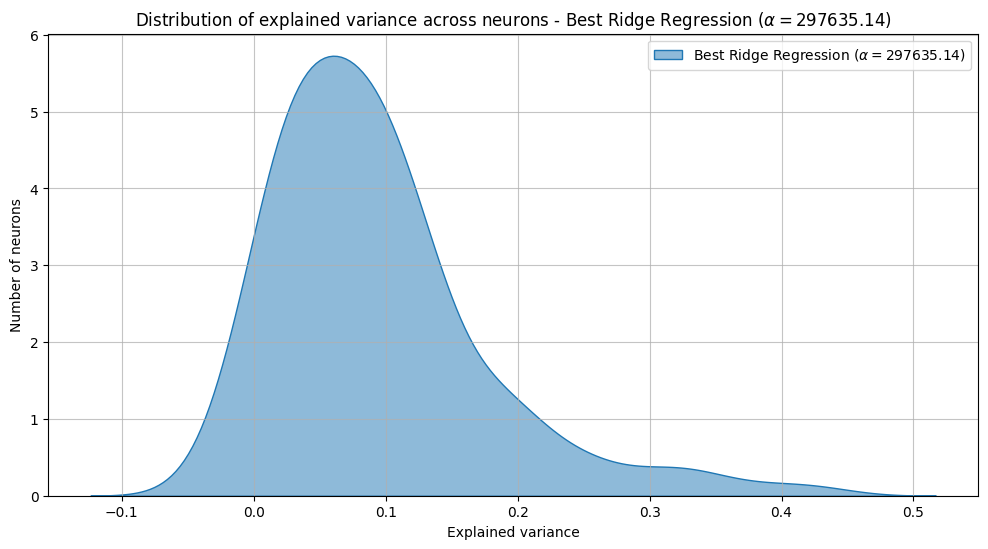

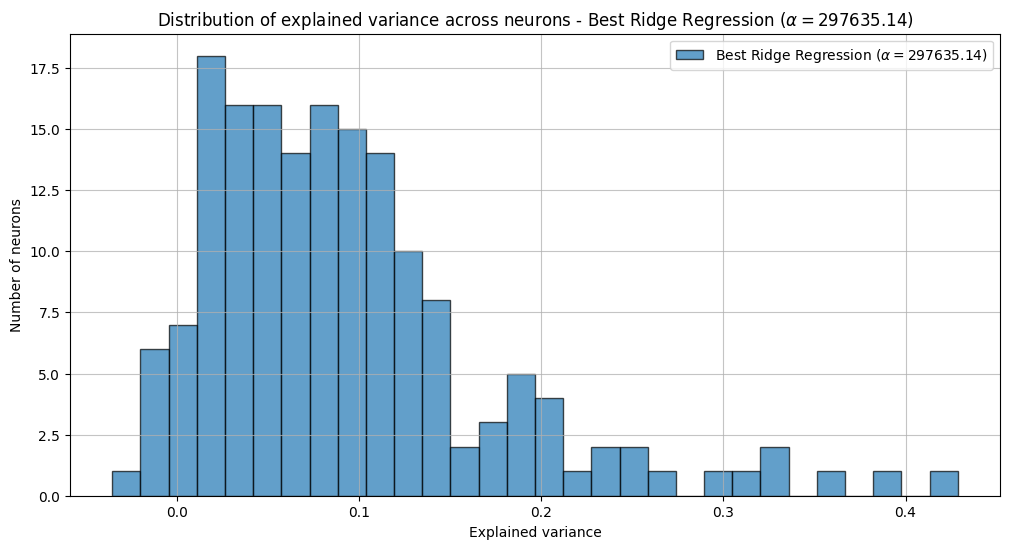

In [70]:
plot_ev_distributions([ev_best_ridge], [model_best_ridge], kde=True)
plot_ev_distributions([ev_best_ridge], [model_best_ridge], kde=False)

##### Tuned ridgeregression with pca

In [71]:
# Perform Ridge regression with cross-validation
ridge_cv_pca = RidgeCV(alphas=alphas, scoring='explained_variance', cv=5)
ridge_cv_pca.fit(X_train_pca, y_train)

# Get the best alpha
best_alpha_pca = ridge_cv.alpha_

print(f"Best alpha: {best_alpha_pca}")

Best alpha: 297635.1441631313


In [72]:
# Evaluate the best model on the validation set
corr_best_ridge_pca, ev_best_ridge_pca = evaluate_model(ridge_cv_pca, X_val_pca, y_val)
mean_corr_best_ridge_pca, mean_ev_best_ridge_pca = np.mean(corr_best_ridge), np.mean(ev_best_ridge)
model_best_ridge_pca = r"Best Ridge Regression on PCA ($\alpha={:.2f}$)".format(best_alpha_pca)
print(model_best_ridge_pca)
print("Mean pearson correlation: {:.4f}".format(mean_corr_best_ridge_pca))
print("Mean explained variance: {:.4f}".format(mean_ev_best_ridge_pca))

Best Ridge Regression on PCA ($\alpha=297635.14$)
Mean pearson correlation: 0.2863
Mean explained variance: 0.0933


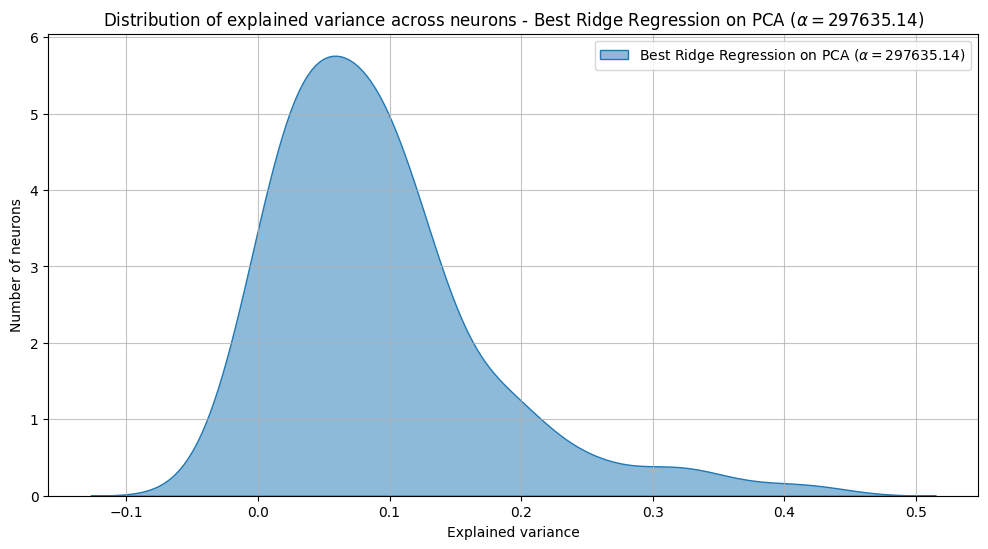

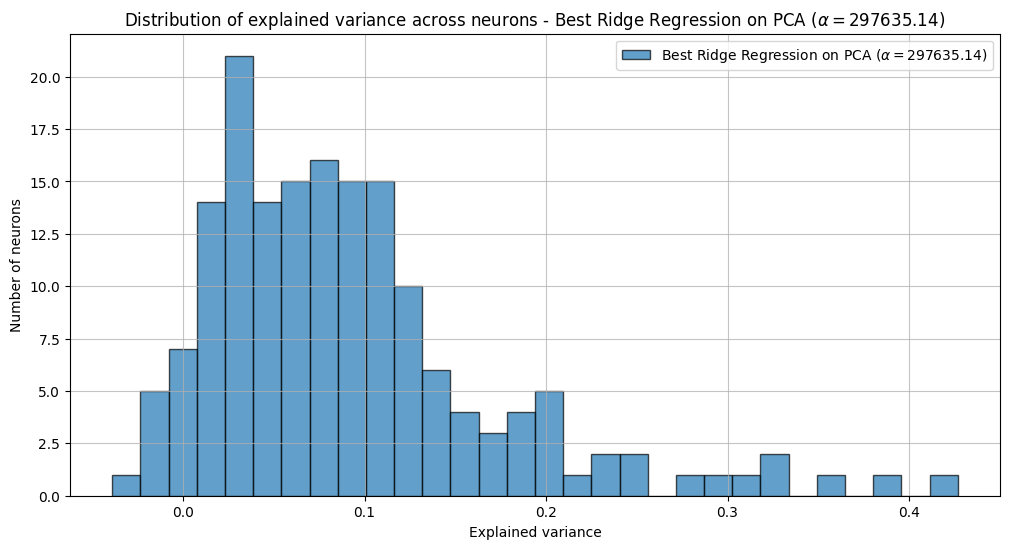

In [73]:
plot_ev_distributions([ev_best_ridge_pca], [model_best_ridge_pca], kde=True)
plot_ev_distributions([ev_best_ridge_pca], [model_best_ridge_pca], kde=False)

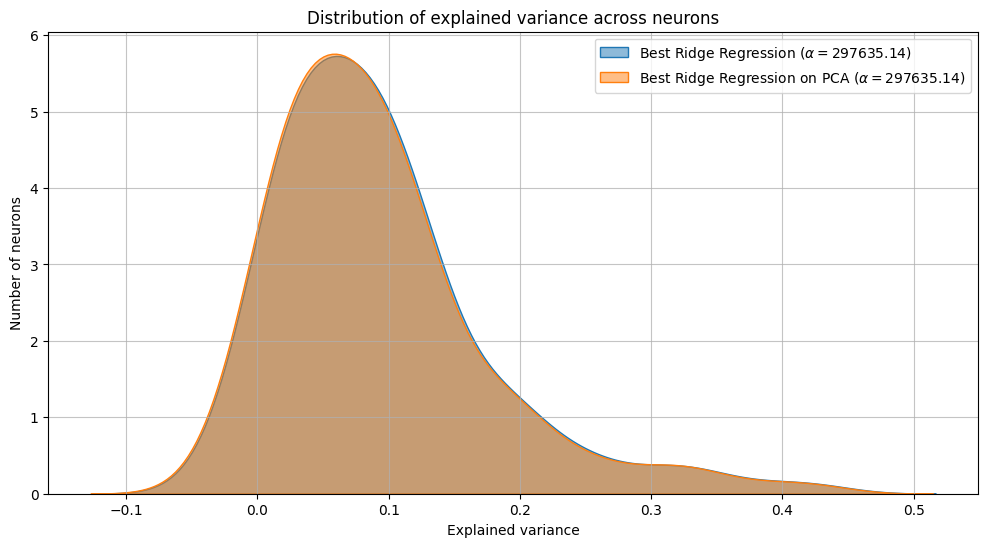

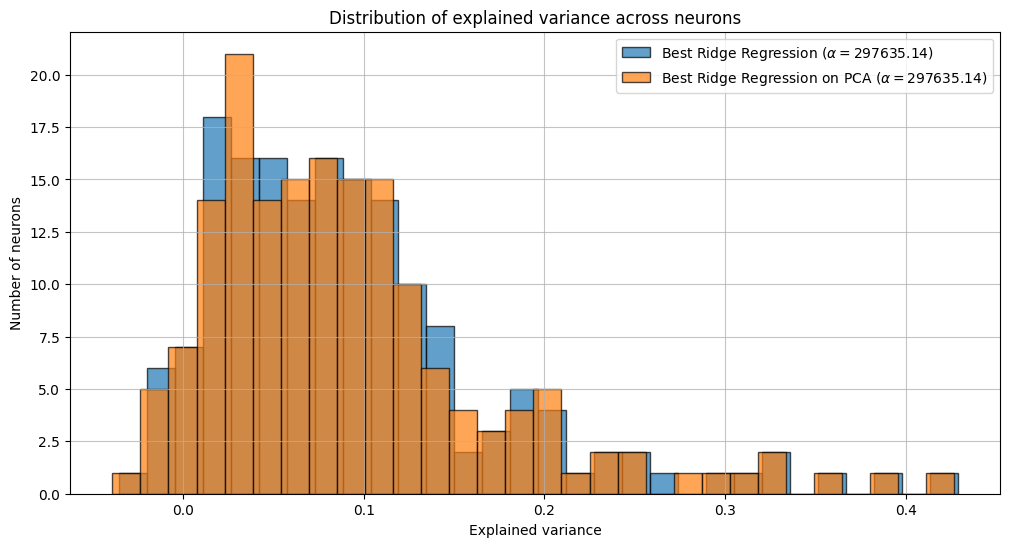

In [74]:
# Compare tuned ridge with PCA, and without PCA
plot_ev_distributions([ev_best_ridge, ev_best_ridge_pca], 
                      [model_best_ridge, model_best_ridge_pca], kde=True)
plot_ev_distributions([ev_best_ridge, ev_best_ridge_pca],
                      [model_best_ridge, model_best_ridge_pca], kde=False)

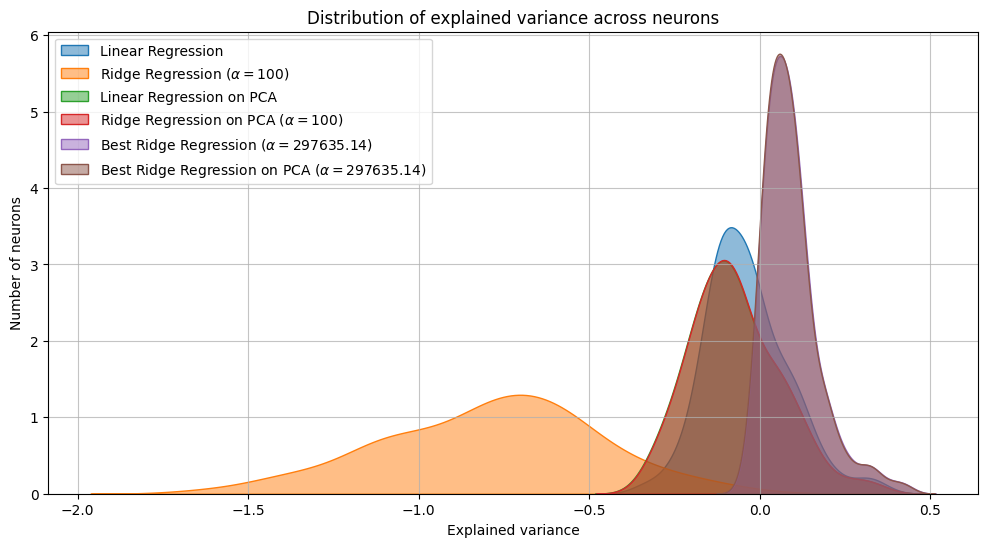

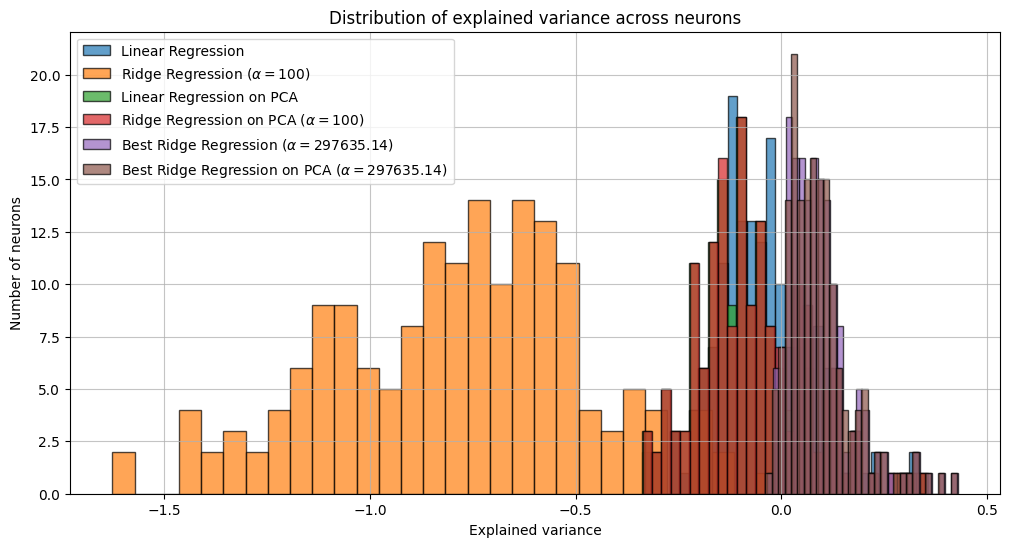

In [75]:
# Compare all models
plot_ev_distributions([ev_linear, ev_ridge, ev_linear_pca, ev_ridge_pca, ev_best_ridge, ev_best_ridge_pca], 
                      [model_linear, model_ridge, model_linear_pca, model_ridge_pca, model_best_ridge, model_best_ridge_pca], kde=True)
plot_ev_distributions([ev_linear, ev_ridge, ev_linear_pca, ev_ridge_pca, ev_best_ridge, ev_best_ridge_pca],
                      [model_linear, model_ridge, model_linear_pca, model_ridge_pca, model_best_ridge, model_best_ridge_pca], kde=False)

In [76]:
# Define the models and their corresponding metrics
models = [model_linear, model_ridge, model_linear_pca, model_ridge_pca, model_best_ridge, model_best_ridge_pca]
explained_variances = [mean_ev_linear, mean_ev_ridge, mean_ev_linear_pca, mean_ev_ridge_pca, mean_ev_best_ridge, mean_ev_best_ridge_pca]
correlations = [mean_corr_linear, mean_corr_ridge, mean_corr_linear_pca, mean_corr_ridge_pca, mean_corr_best_ridge, mean_corr_best_ridge_pca]

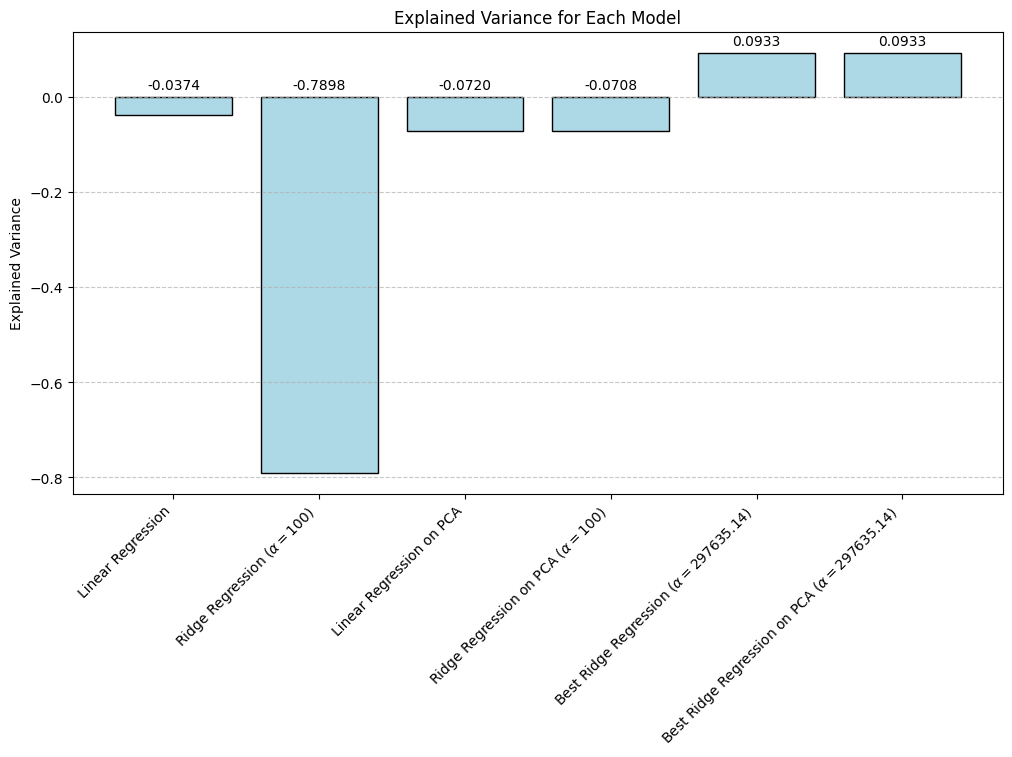

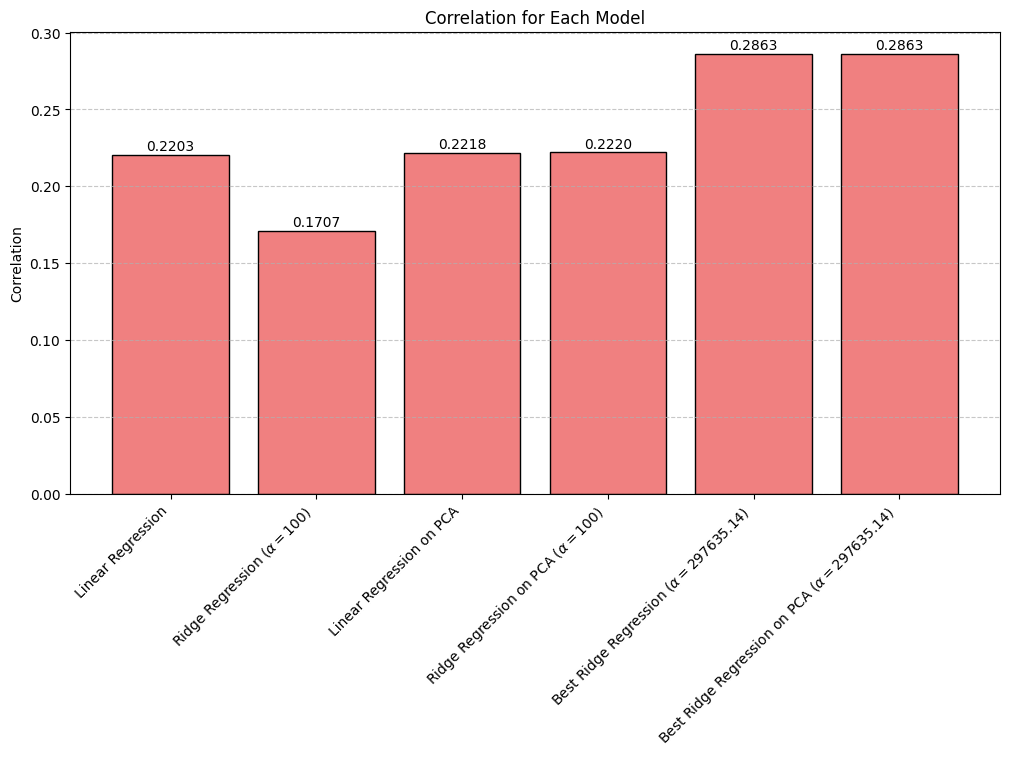

In [77]:
# Plot explained variance for each model
plt.figure(figsize=(12, 6))
plt.bar(models, explained_variances, color='lightblue', edgecolor='black')
for i, ev in enumerate(explained_variances):
    plt.text(i, max(0, ev) + 0.01, f"{ev:.4f}", ha='center', va='bottom', fontsize=10)
plt.title("Explained Variance for Each Model")
plt.ylabel("Explained Variance")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Plot correlation for each model
plt.figure(figsize=(12, 6))
plt.bar(models, correlations, color='lightcoral', edgecolor='black')
for i, corr in enumerate(correlations):
    plt.text(i, corr + 0.001, f"{corr:.4f}", ha='center', va='bottom', fontsize=10)
plt.title("Correlation for Each Model")
plt.ylabel("Correlation")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Part 2: Predict the neural activity with the task-driven modeling approach

As you have seen in the class, the underlying hypothesis of task-driven modeling is that training the network to perform a relevant behavioral task makes the network to develop representations that resemble the ones of the biological brain. Let's test this hypothesis by loading a pre-trained ResNet50 model and use the activations of each layer to predict the neural activity. Follow these steps:

- Give as input to the network the stimuli and extract the corresponding activations of the following layers ['conv1','layer1','layer2','layer3','layer4','avgpool']
- Compute the 1000 PCs for each layer activation. (Careful that you don't want to store all activations together at the same time because it won't fit in the memory. Therefore, compute the activations and corresponding PCs for each layer and store only the computed PCs).
- Use the PCs of each layer to predict the neural activity using the linear regression models you developed before.
- Compute the goodness of fit using the correlation and explained variance metrics. Do you predict the neural activity better than before?
- Plot the distribution of explained variance with respect to the layer of the network (order them based on the depth). How does the neural activity changes across the model layers, can you make some statements about it?
- Compare the predictions that you obtained using one layer of the pretrained model and the one obtained using the same layer but from a randomly initialized model. Which network can better predict the neural activity and why?

In [78]:
import torch
import torch.utils.data as data
from torch.utils.data import DataLoader
from torchvision.models import resnet50, ResNet50_Weights
from sklearn.decomposition import PCA
import numpy as np
from tqdm import tqdm
import pickle

In [79]:
def extract_layer_outputs(model, data_loader, layers):
    """
    Extracts raw activations from specified layers for all samples in data_loader.

    Args:
        model (torch.nn.Module): PyTorch model with registered layers.
        data_loader (DataLoader): DataLoader providing input batches.
        layers (list of str): Layer names to hook and extract activations.

    Returns:
        dict: Mapping from layer name to concatenated numpy array of activations.
    """
    activations = {name: [] for name in layers}

    # Register hooks for each layer to capture outputs
    hooks = []
    for name in layers:
        layer = getattr(model, name)
        hook = layer.register_forward_hook(
            lambda module, inp, out, layer_name=name: activations[layer_name].append(out.detach().cpu().numpy())
        )
        hooks.append(hook)

    # Run forward passes without gradient tracking
    model.eval()
    with torch.no_grad():
        for batch in tqdm(data_loader, desc="Extracting activations"):
            # Prepare input tensor
            x = torch.from_numpy(np.stack(batch).astype(np.float32))
            _ = model(x)

    # Remove hooks
    for hook in hooks:
        hook.remove()

    # Concatenate collected outputs per layer
    return {name: np.concatenate(activations[name], axis=0) for name in layers}

In [80]:
def compute_pca(train_acts, val_acts, num_components):
    """
    Fits PCA on training activations and transforms both train and validation data.

    Args:
        train_acts (np.ndarray): Activations for training data of shape (N, ...).
        val_acts (np.ndarray): Activations for validation data of shape (M, ...).
        num_components (int): Number of PCA components to keep.

    Returns:
        tuple: (train_pca, val_pca) transformed arrays.
    """
    # Reshape to 2D: (n_samples, features)
    n_train = train_acts.shape[0]
    train_flat = train_acts.reshape(n_train, -1)

    n_val = val_acts.shape[0]
    val_flat = val_acts.reshape(n_val, -1)

    pca = PCA(n_components=num_components)
    pca.fit(train_flat)

    train_pca = pca.transform(train_flat)
    val_pca = pca.transform(val_flat)

    return train_pca, val_pca

In [81]:
def save_dict(data_dict, filepath):
    """
    Saves a Python object to a pickle file.

    Args:
        data_dict (any): Object to pickle.
        filepath (str): Path to save the pickle file.
    """
    os.makedirs(os.path.dirname(filepath), exist_ok=True)
    with open(filepath, "wb") as f:
        pickle.dump(data_dict, f)

In [83]:
# Toggle whether to rerun model inference or load precomputed features
run_model = False

# PCA parameters
layers = ['conv1', 'layer1', 'layer2', 'layer3', 'layer4', 'avgpool']
num_components = 1000
batch_size = 64

if run_model:
    # Load pretrained ResNet50
    weights = ResNet50_Weights.IMAGENET1K_V2
    model = resnet50(weights=weights)

    # Prepare data loaders (replace with actual dataset variables)
    train_loader = DataLoader(stimulus_train, batch_size=batch_size, shuffle=False)
    val_loader = DataLoader(stimulus_val, batch_size=batch_size, shuffle=False)

    # Extract raw activations
    train_acts = extract_layer_outputs(model, train_loader, layers)
    val_acts = extract_layer_outputs(model, val_loader, layers)

    # Compute PCA for each layer and collect results
    pca_train = {}
    pca_val = {}
    for layer in tqdm(layers):
        pca_train[layer], pca_val[layer] = compute_pca(
            train_acts[layer], val_acts[layer], num_components
        )

    # Save PCA-transformed activations
    save_dict(pca_train, 'data/pca_dict_train.pkl')
    save_dict(pca_val, 'data/pca_dict_val.pkl')
else:
    # Load precomputed PCA features
    pca_train = pickle.load(open('data/pca_dict_train.pkl', 'rb'))
    pca_val = pickle.load(open('data/pca_dict_val.pkl', 'rb'))


In [84]:
def compute_corr(y_true, y_pred, divide=False):
    """
    Compute Pearson correlation coefficient(s) between y_true and y_pred.

    Parameters
    ----------
    y_true : array-like, shape (n_samples, n_neurons)
        Ground-truth values.
    y_pred : array-like, shape (n_samples, n_neurons)
        Predicted values.
    divide : bool, default=False
        If True, return per-neuron correlations (one per column).
        If False, return a single correlation over all entries.

    Returns
    -------
    float or np.ndarray
        Correlation coefficient (scalar) if divide=False, or
        1-D array of length n_neurons if divide=True.
    """

    
    if divide:
        # Compute Pearson r for each column separately
        corrs = []
        for i in range(y_true.shape[1]):
            # np.corrcoef returns the 2×2 correlation matrix
            r = np.corrcoef(y_true[:, i], y_pred[:, i])[0, 1]
            corrs.append(r)
        return np.array(corrs)
    else:
        # Flatten and compute overall correlation
        return np.corrcoef(y_true.ravel(), y_pred.ravel())[0, 1]

In [85]:
alphas = np.logspace(0, 8, 20) 

In [86]:
def ridgecv_eval(X_tr, y_tr, X_val, y_val):
    # instantiate RidgeCV with explained_variance scoring
    model = RidgeCV(
        alphas=alphas,
        scoring='explained_variance',  # maximize EV
        cv=5,
        store_cv_results=False,         # set True if you want CV predictions
        fit_intercept=True
    )
    model.fit(X_tr, y_tr)
    
    # best α
    best_alpha = model.alpha_
    
    # predict & score
    y_pred = model.predict(X_val)
    ev   = explained_variance_score(y_val, y_pred)
    corr = compute_corr(y_val, y_pred)
    return best_alpha, ev, corr

In [87]:
# Initialize lists to store results
ev_layer = []
corr_layer = []

for name in tqdm(layers):
    
    # prepare the data
    X_train = pca_train[name]
    X_val = pca_val[name]
    y_train = spikes_train
    y_val = spikes_val
    
    best_alpha, ev, corr = ridgecv_eval(X_train, y_train, X_val, y_val)
    ev_layer.append(ev)
    corr_layer.append(corr)

100%|█████████████████████████████████████████████| 6/6 [00:26<00:00,  4.50s/it]


In [88]:
def plot_bar_with_labels(x, y, title, ylabel, color):
    """
    Creates a bar plot of y over x, annotates each bar with its height.
    """
    plt.figure(figsize=(12, 6))
    bars = plt.bar(x, y, color=color, edgecolor='black')
    plt.axhline(0, color='black', linestyle="--", linewidth=0.8)
    plt.title(title)
    plt.ylim(-0.1, 1)
    plt.xlabel('Layer')
    plt.ylabel(ylabel)
    plt.xticks(rotation=45)

    # Annotate each bar
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.03,
            f"{height:.2f}",
            ha='center',
            va='bottom',
            fontsize=10
        )

    plt.tight_layout()
    plt.show()



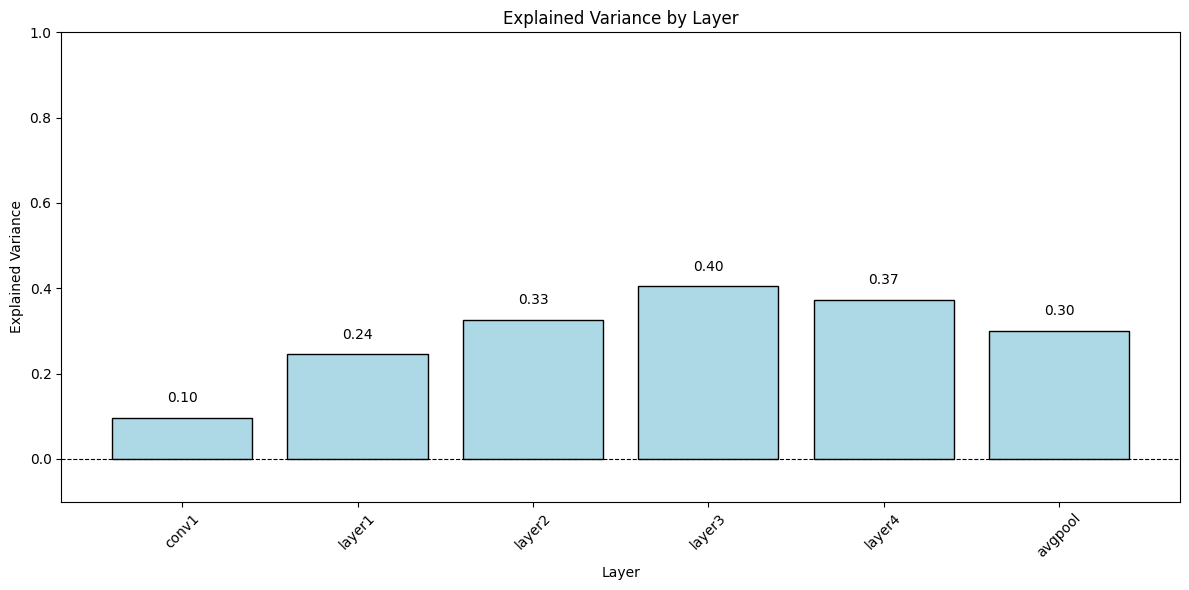

In [89]:
# Plot 1: Explained Variance
plot_bar_with_labels(
    layers,
    ev_layer,
    title='Explained Variance by Layer',
    ylabel='Explained Variance',
    color='lightblue'
)

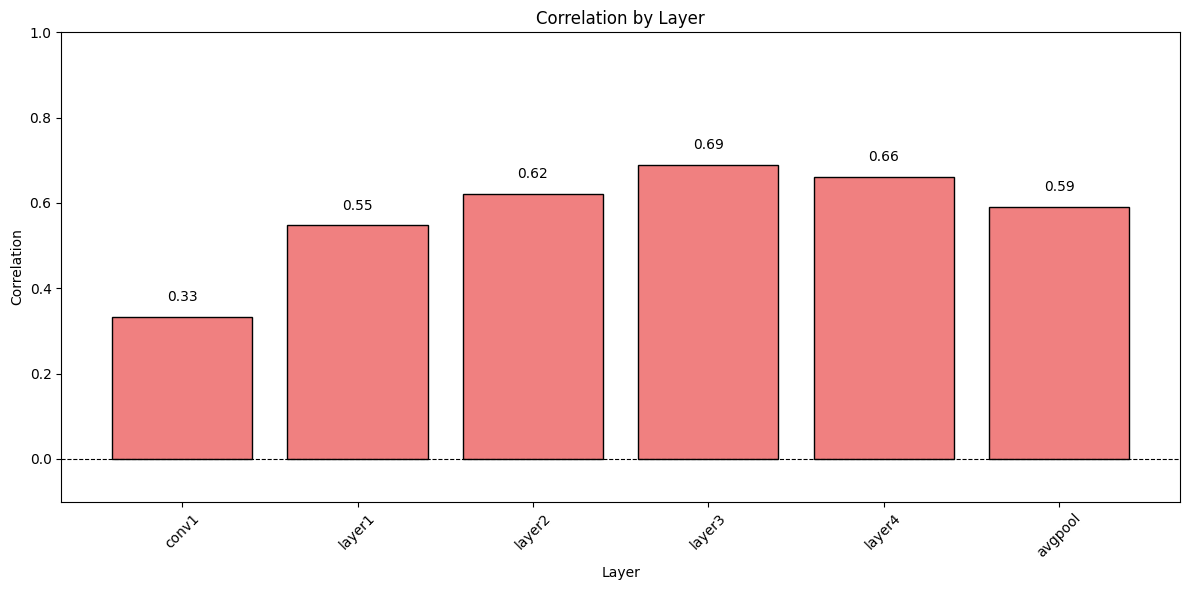

In [90]:
# Plot 2: Correlation
plot_bar_with_labels(
    layers,
    corr_layer,
    title='Correlation by Layer',
    ylabel='Correlation',
    color='lightcoral'
)

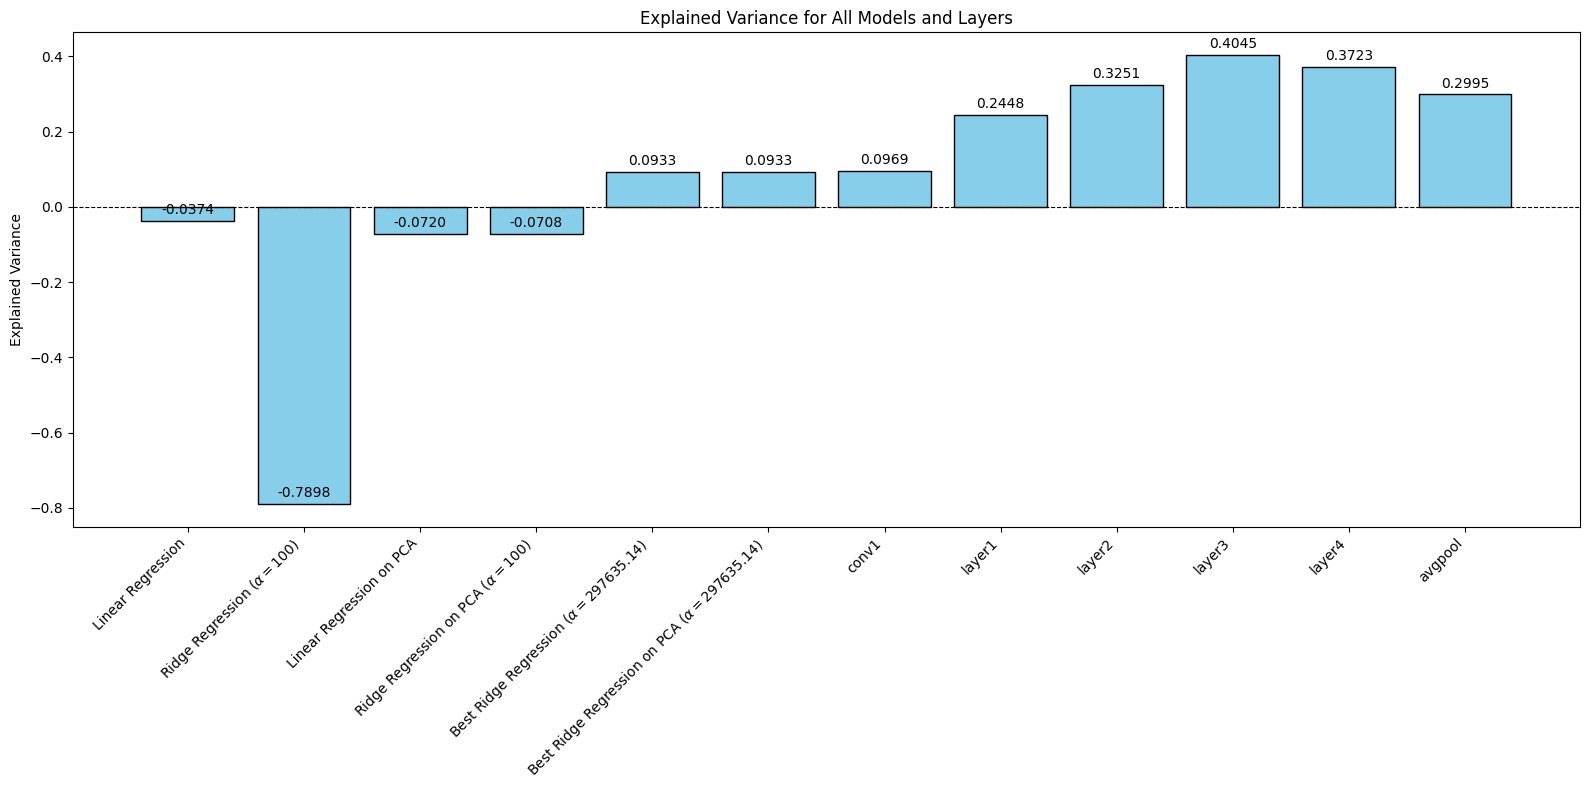

In [91]:
# Combine explained variance from Part 1 models and each layer
all_models = models + layers
all_explained_variances = explained_variances + ev_layer

# Plot the bar chart
plt.figure(figsize=(16, 8))
bars = plt.bar(all_models, all_explained_variances, color='skyblue', edgecolor='black')
plt.axhline(0, color='black', linestyle="--", linewidth=0.8)
plt.title("Explained Variance for All Models and Layers")
plt.ylabel("Explained Variance")
plt.xticks(rotation=45, ha='right')

# Annotate each bar with its value
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.01,
        f"{height:.4f}",
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.tight_layout()
plt.show()

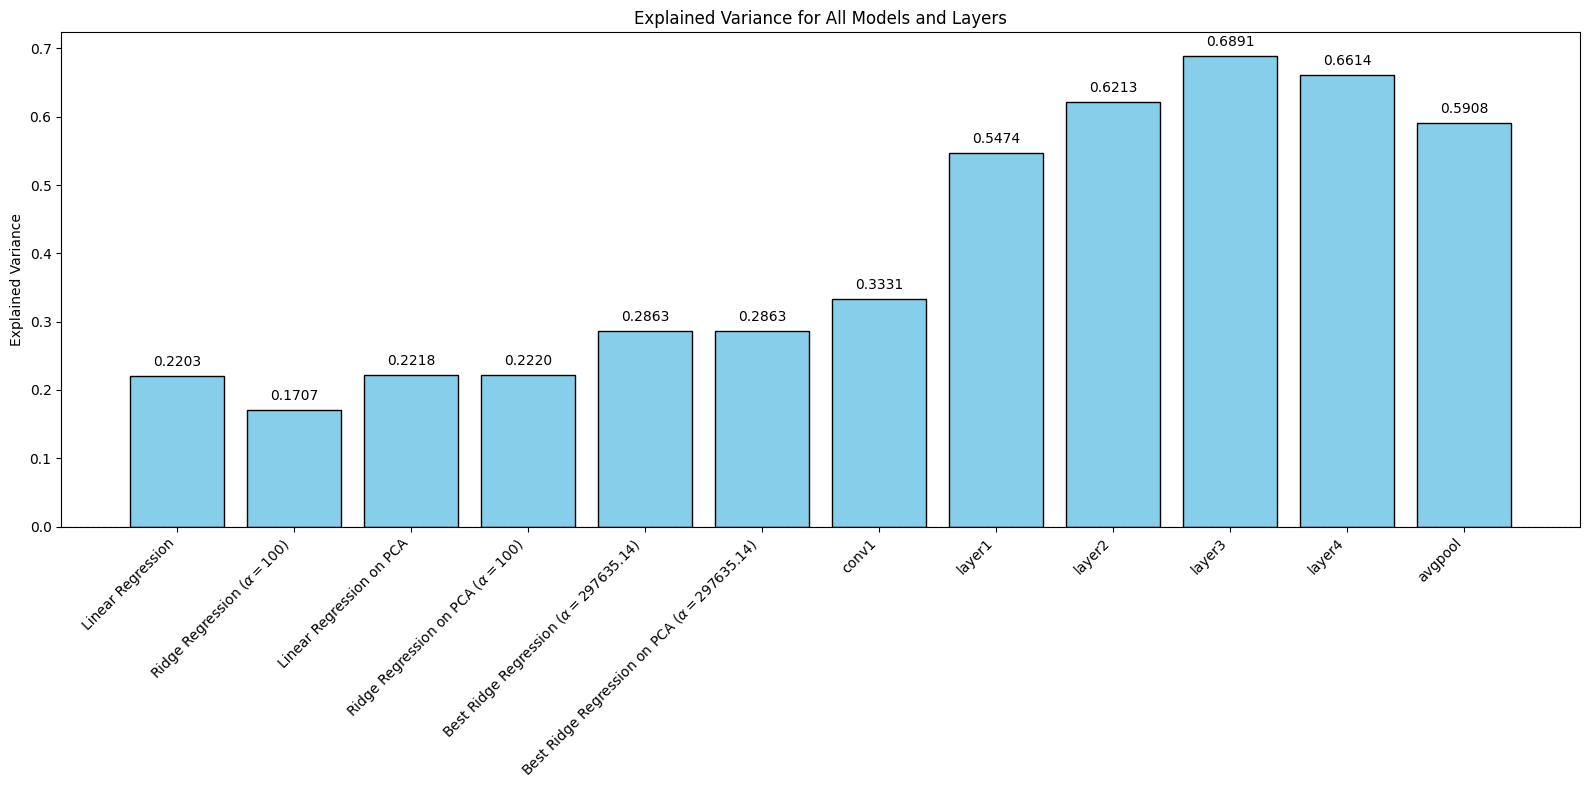

In [92]:
# Combine correlation from Part 1 models and each layer
all_models = models + layers
all_correlations = correlations + corr_layer

# Plot the bar chart
plt.figure(figsize=(16, 8))
bars = plt.bar(all_models, all_correlations, color='skyblue', edgecolor='black')
plt.axhline(0, color='black', linestyle="--", linewidth=0.8)
plt.title("Explained Variance for All Models and Layers")
plt.ylabel("Explained Variance")
plt.xticks(rotation=45, ha='right')

# Annotate each bar with its value
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.01,
        f"{height:.4f}",
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.tight_layout()
plt.show()

In [93]:
# Toggle whether to rerun model inference or load precomputed features
run_model = False

# PCA parameters
layers = ['conv1', 'layer1', 'layer2', 'layer3', 'layer4', 'avgpool']
num_components = 1000
batch_size = 64

if run_model:
    # Load pretrained ResNet50
    model = resnet50(weights=None)

    # Prepare data loaders (replace with actual dataset variables)
    train_loader = DataLoader(stimulus_train, batch_size=batch_size, shuffle=False)
    val_loader = DataLoader(stimulus_val, batch_size=batch_size, shuffle=False)

    # Extract raw activations
    train_acts = extract_layer_outputs(model, train_loader, layers)
    val_acts = extract_layer_outputs(model, val_loader, layers)

    # Compute PCA for each layer and collect results
    pca_train_random = {}
    pca_val_random = {}
    for layer in tqdm(layers):
        pca_train_random[layer], pca_val_random[layer] = compute_pca(
            train_acts[layer], val_acts[layer], num_components
        )

    # Save PCA-transformed activations
    save_dict(pca_train_random, 'data/pca_dict_train_random.pkl')
    save_dict(pca_val_random, 'data/pca_dict_val_random.pkl')
else:
    # Load precomputed PCA features
    pca_train_random = pickle.load(open('data/pca_dict_train_random.pkl', 'rb'))
    pca_val_random = pickle.load(open('data/pca_dict_val_random.pkl', 'rb'))

In [94]:
# Initialize lists to store results
ev_layer = []
corr_layer = []

for name in tqdm(layers):
    
    # prepare the data
    X_train = pca_train[name]
    X_val = pca_val[name]
    y_train = spikes_train
    y_val = spikes_val
    
    best_alpha, ev, corr = ridgecv_eval(X_train, y_train, X_val, y_val)
    ev_layer.append(ev)
    corr_layer.append(corr)

100%|█████████████████████████████████████████████| 6/6 [00:26<00:00,  4.40s/it]


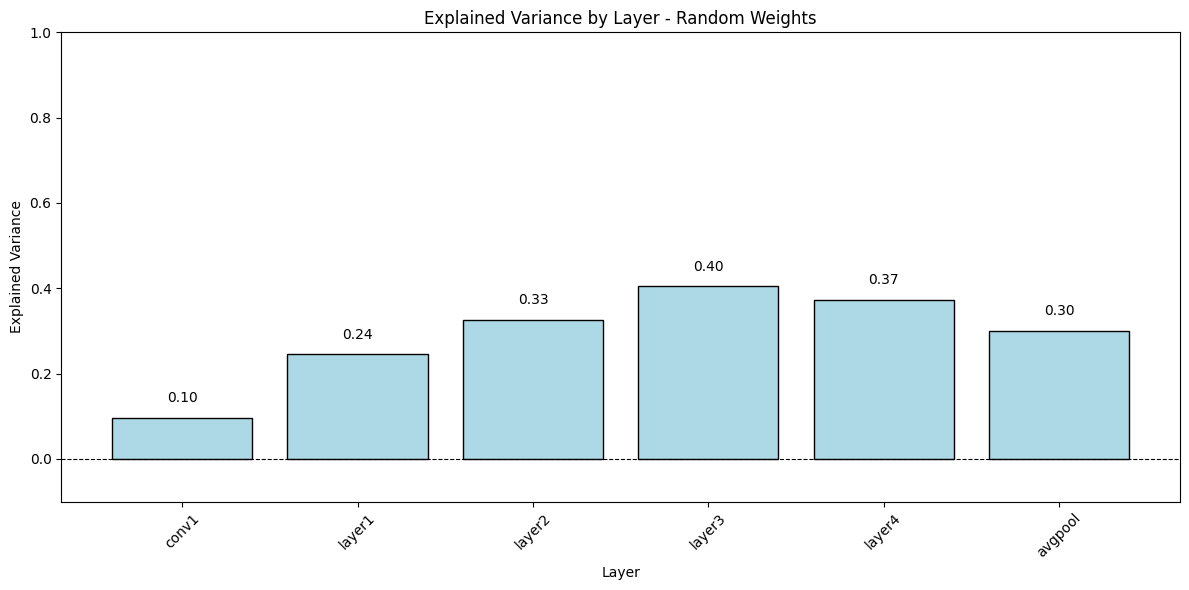

In [95]:
# Plot 1: Explained Variance
plot_bar_with_labels(
    layers,
    ev_layer,
    title='Explained Variance by Layer - Random Weights',
    ylabel='Explained Variance',
    color='lightblue'
)

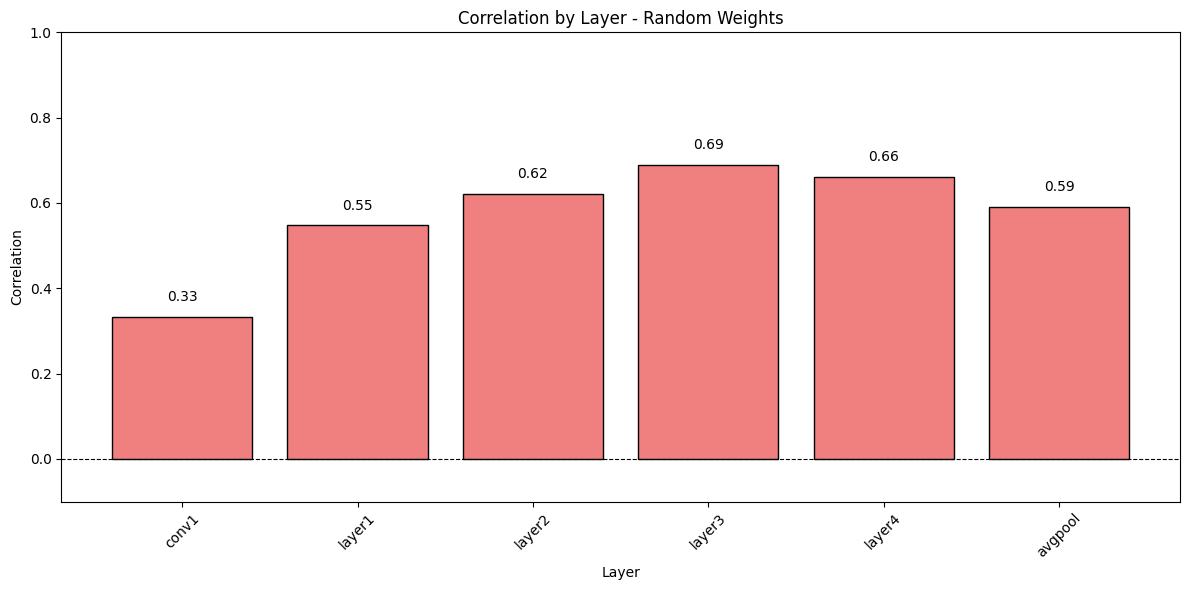

In [96]:
# Plot 2: Correlation
plot_bar_with_labels(
    layers,
    corr_layer,
    title='Correlation by Layer - Random Weights',
    ylabel='Correlation',
    color='lightcoral'
)

In [100]:
name = 'layer3'

X_train = pca_train[name]
X_train_random = pca_train_random[name]

X_val = pca_val[name]
X_val_random = pca_val_random[name]

y_train = spikes_train
y_val = spikes_val


# In the case we use the exact same alpha as in part 1
ridge = Ridge(alpha=297635.1441631313, fit_intercept=True)
ridge.fit(X_train, y_train)
y_val_pred = ridge.predict(X_val)
ev = explained_variance_score(y_val, y_val_pred)
corr = compute_corr(y_val, y_val_pred)

ridge_random = Ridge(alpha=297635.1441631313, fit_intercept=True)
ridge_random.fit(X_train_random, y_train)
y_val_pred_random = ridge.predict(X_val_random)
ev_random = explained_variance_score(y_val, y_val_pred_random)
corr_random = compute_corr(y_val, y_val_pred_random)


print('Explained variance for imagenetik weights is:', ev)
print('Explained variance for random weights is:', ev_random)

print('Correlation for imagenetik weights is:', corr)
print('Correlation for random weights is:', corr_random)

Explained variance for imagenetik weights is: 0.3696386218070984
Explained variance for random weights is: -9.567715644836426
Correlation for imagenetik weights is: 0.6710897849807073
Correlation for random weights is: -0.041823939963720975


In [101]:
# Fit & evaluate both (tuned ridge)

alpha_real, ev_real, corr_real = ridgecv_eval(X_train, y_train, X_val, y_val)
alpha_rand, ev_rand, corr_rand = ridgecv_eval(X_train_random, y_train, X_val_random, y_val)

print(rf"Imagenetik  → best $\alpha$  = {alpha_real:.3f}  |  ev = {ev_real:.4f}  |  corr = {corr_real:.4f}")
print(rf"Random      → best $\alpha$ = {alpha_rand:.3f}  |  ev = {ev_rand:.4f}  |  corr = {corr_rand:.4f}")

Imagenetik  → best $\alpha$  = 112883.789  |  ev = 0.4045  |  corr = 0.6891
Random      → best $\alpha$ = 784759.970  |  ev = 0.1851  |  corr = 0.4656


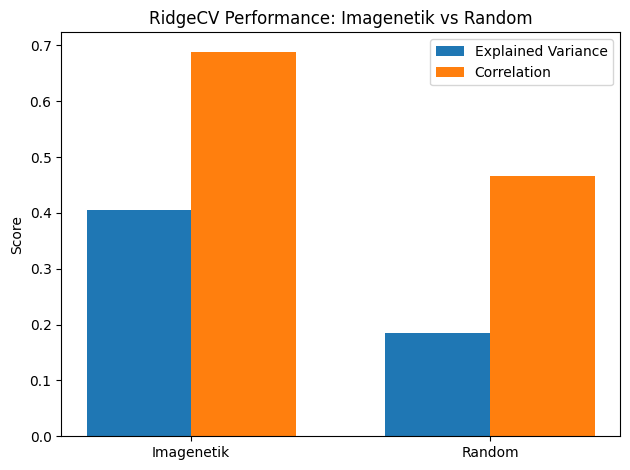

In [ ]:
# Plot comparison
labels      = ['Imagenetik_v2', 'Random']
ev_scores   = [ev_real,   ev_rand]
corr_scores = [corr_real, corr_rand]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots()
ax.bar(x - width/2, ev_scores,   width, label='Explained Variance')
ax.bar(x + width/2, corr_scores, width, label='Correlation')

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('Score')
ax.set_title('RidgeCV Performance: Imagenetik vs Random')
ax.legend()
plt.tight_layout()
plt.show()
